# Student Performance Decision-Support System

## Tree Models Notebook


## 1. Setup

In [65]:
from pathlib import Path
import sys

print(sys.executable)

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Find the repository root
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Allow imports from the src folder
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)
print("src folder exists:", (PROJECT_ROOT / "src").exists())

from src.config import (
    EARLY_WARNING_EXPERIMENT,
    PROGRESS_INFORMED_EXPERIMENT,
    RANDOM_STATE,
    TEST_INDICES_PATH,
    TRAIN_INDICES_PATH,
)
from src.data import (
    create_target,
    get_feature_sets,
    load_student_data,
)
from src.evaluation import (
    attach_cv_results,
    compare_model_results,
    cross_validate_classifier,
    evaluate_classifier,
    evaluate_subgroups,
    plot_confusion_matrix,
)
from src.preprocessing import build_model_pipeline

print("Project imports completed successfully.")


c:\Users\USER\Desktop\clone\.venv\Scripts\python.exe
Current directory: c:\Users\USER\student-performance-decision-support\notebooks
Project root: c:\Users\USER\student-performance-decision-support
src folder exists: True
Project imports completed successfully.


## 2. Load the shared dataset, feature sets, and split

In [66]:
# Rebuild the dataset and feature sets exactly as the foundation notebook did
df_raw = load_student_data()
df = create_target(df_raw)

X_base, X_early, X_progress, y = get_feature_sets(df)

print("Base feature shape:", X_base.shape)
print("Early-warning feature shape:", X_early.shape)
print("Progress-informed feature shape:", X_progress.shape)


Base feature shape: (649, 32)
Early-warning feature shape: (649, 30)
Progress-informed feature shape: (649, 32)


In [67]:
# Identify numeric and categorical columns the same way the foundation notebook did
numeric_features = X_base.select_dtypes(include=["number"]).columns.tolist()

categorical_features = X_base.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numerical features: 15
Categorical features: 17


C:\Users\USER\AppData\Local\Temp\ipykernel_7660\173167390.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_base.select_dtypes(


In [68]:
numeric_features_early = [f for f in numeric_features if f in X_early.columns]
categorical_features_early = [f for f in categorical_features if f in X_early.columns]
numeric_features_prog = [f for f in numeric_features if f in X_progress.columns]
categorical_features_prog = [f for f in categorical_features if f in X_progress.columns]
print("Early numeric:", numeric_features_early)
print("Progress numeric:", numeric_features_prog)

Early numeric: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Progress numeric: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [69]:
# Load the shared row indices saved by the foundation notebook
train_indices = pd.read_csv(TRAIN_INDICES_PATH).iloc[:, 0].values
test_indices = pd.read_csv(TEST_INDICES_PATH).iloc[:, 0].values

print("Training rows:", len(train_indices))
print("Testing rows:", len(test_indices))


Training rows: 519
Testing rows: 130


In [70]:
def make_split(X):
    X_train = X.loc[train_indices]
    X_test = X.loc[test_indices]
    y_train = y.loc[train_indices]
    y_test = y.loc[test_indices]
    return X_train, X_test, y_train, y_test


# Early-warning split (no G1, G2)
X_train_early, X_test_early, y_train_early, y_test_early = make_split(X_early)

# Progress-informed split (includes G1, G2)
X_train_prog, X_test_prog, y_train_prog, y_test_prog = make_split(X_progress)

print("Early-warning train/test:", X_train_early.shape, X_test_early.shape)
print("Progress-informed train/test:", X_train_prog.shape, X_test_prog.shape)


Early-warning train/test: (519, 30) (130, 30)
Progress-informed train/test: (519, 32) (130, 32)


In [71]:
# Collect results from all four combinations here
all_results = []


## 3. Decision Tree — early_warning experiment


In [72]:
# Baseline decision tree, default hyperparameters

tree_pipeline_baseline = build_model_pipeline(
    numeric_features=numeric_features_early,
    categorical_features=categorical_features_early,
    classifier=DecisionTreeClassifier(random_state=RANDOM_STATE),
)

result_tree_early_baseline = evaluate_classifier(
    tree_pipeline_baseline,
    X_train_early,
    X_test_early,
    y_train_early,
    y_test_early,
    experiment_name=EARLY_WARNING_EXPERIMENT,
    model_name="decision_tree_baseline",
)

print("Training accuracy:", result_tree_early_baseline["training_accuracy"])
print("Testing accuracy:", result_tree_early_baseline["testing_accuracy"])
print("Recall:", result_tree_early_baseline["support_recall"])


Training accuracy: 1.0
Testing accuracy: 0.8153846153846154
Recall: 0.25


**Overfitting check:** compare training vs. testing accuracy above.



In [ ]:
# Tuned decision tree
# max_depth limits how deep the tree can grow, directly controlling overfitting
# min_samples_leaf forces each leaf to represent a meaningful number of students
tree_pipeline_early = build_model_pipeline(
    numeric_features=numeric_features_early,
    categorical_features=categorical_features_early,
    classifier=DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=5,
        min_samples_leaf=15,
    ),
)

result_tree_early = evaluate_classifier(
    tree_pipeline_early,
    X_train_early,
    X_test_early,
    y_train_early,
    y_test_early,
    experiment_name=EARLY_WARNING_EXPERIMENT,
    model_name="decision_tree",
)

cv_summary_tree_early = cross_validate_classifier(
    tree_pipeline_early, X_train_early, y_train_early
)
result_tree_early = attach_cv_results(result_tree_early, cv_summary_tree_early)

print(result_tree_early)


{'experiment_name': 'early_warning', 'model_name': 'decision_tree', 'training_accuracy': 0.8901734104046243, 'testing_accuracy': 0.8153846153846154, 'support_precision': 0.3888888888888889, 'support_recall': 0.35, 'support_f1': 0.3684210526315789, 'roc_auc': 0.7518181818181817, 'cv_mean': np.float64(0.3625), 'cv_std': np.float64(0.1828592354790974), 'confusion_matrix': array([[99, 11],
       [13,  7]])}


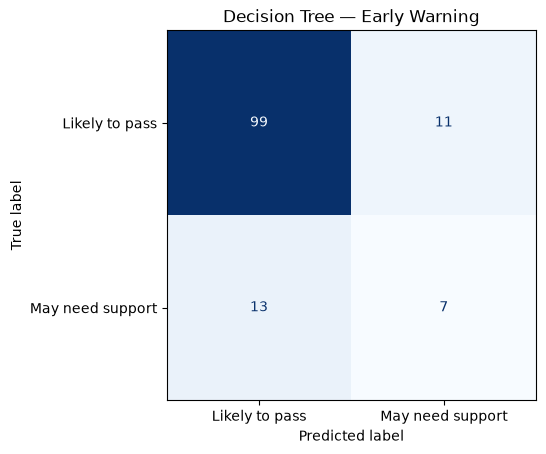

In [74]:
plot_confusion_matrix(
    result_tree_early["confusion_matrix"],
    title="Decision Tree — Early Warning",
)

all_results.append(result_tree_early)


## 4. Decision Tree — progress_informed experiment

In [ ]:
tree_pipeline_prog = build_model_pipeline(
    numeric_features=numeric_features_prog,
    categorical_features=categorical_features_prog,
    classifier=DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=4,
        min_samples_leaf=10,
    ),
)

result_tree_prog = evaluate_classifier(
    tree_pipeline_prog,
    X_train_prog,
    X_test_prog,
    y_train_prog,
    y_test_prog,
    experiment_name=PROGRESS_INFORMED_EXPERIMENT,
    model_name="decision_tree",
)

cv_summary_tree_prog = cross_validate_classifier(
    tree_pipeline_prog, X_train_prog, y_train_prog
)
result_tree_prog = attach_cv_results(result_tree_prog, cv_summary_tree_prog)

print(result_tree_prog)


{'experiment_name': 'progress_informed', 'model_name': 'decision_tree', 'training_accuracy': 0.9499036608863198, 'testing_accuracy': 0.9153846153846154, 'support_precision': 0.7368421052631579, 'support_recall': 0.7, 'support_f1': 0.717948717948718, 'roc_auc': 0.9334090909090909, 'cv_mean': np.float64(0.7125), 'cv_std': np.float64(0.18371173070873836), 'confusion_matrix': array([[105,   5],
       [  6,  14]])}


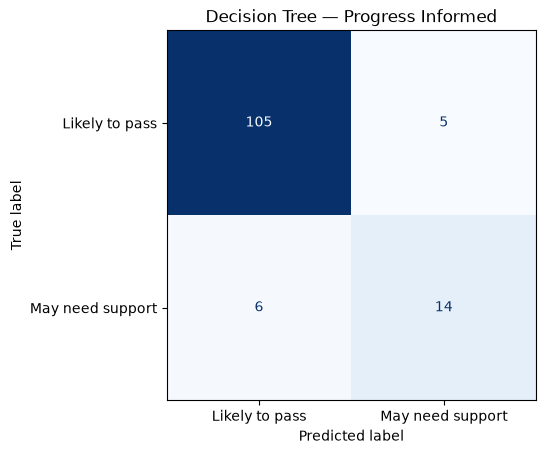

In [76]:
plot_confusion_matrix(
    result_tree_prog["confusion_matrix"],
    title="Decision Tree — Progress Informed",
)

all_results.append(result_tree_prog)


## 5. Random Forest — early_warning experiment

In [77]:
# n_estimators controls how many trees are averaged — more trees generally
# means more stable predictions, at the cost of training time
# class_weight="balanced" up-weights the minority class, which can help recall


forest_pipeline_early = build_model_pipeline(
    numeric_features=numeric_features_early,
    categorical_features=categorical_features_early,
    classifier=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=15,
        class_weight="balanced",
    ),
)
result_forest_early = evaluate_classifier(
    forest_pipeline_early,
    X_train_early,
    X_test_early,
    y_train_early,
    y_test_early,
    experiment_name=EARLY_WARNING_EXPERIMENT,
    model_name="random_forest",
)

cv_summary_forest_early = cross_validate_classifier(
    forest_pipeline_early, X_train_early, y_train_early
)
result_forest_early = attach_cv_results(result_forest_early, cv_summary_forest_early)

print(result_forest_early)


{'experiment_name': 'early_warning', 'model_name': 'random_forest', 'training_accuracy': 0.7861271676300579, 'testing_accuracy': 0.7769230769230769, 'support_precision': 0.38461538461538464, 'support_recall': 0.75, 'support_f1': 0.5084745762711864, 'roc_auc': 0.8163636363636364, 'cv_mean': np.float64(0.75), 'cv_std': np.float64(0.07905694150420949), 'confusion_matrix': array([[86, 24],
       [ 5, 15]])}


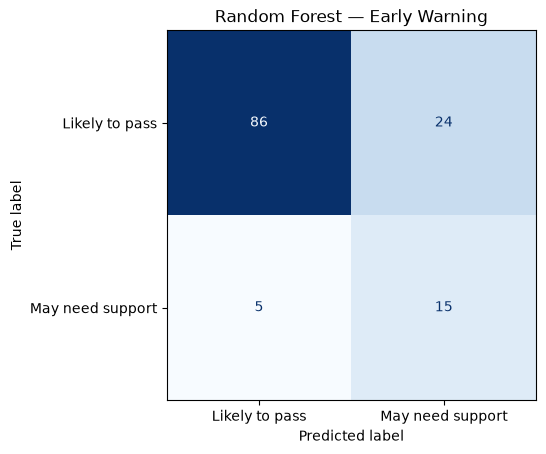

In [78]:
plot_confusion_matrix(
    result_forest_early["confusion_matrix"],
    title="Random Forest — Early Warning",
)

all_results.append(result_forest_early)


## 6. Random Forest — progress_informed experiment

In [79]:
forest_pipeline_prog = build_model_pipeline(
    numeric_features=numeric_features_prog,
    categorical_features=categorical_features_prog,
    classifier=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=15,
        class_weight="balanced",
    ),
)

result_forest_prog = evaluate_classifier(
    forest_pipeline_prog,
    X_train_prog,
    X_test_prog,
    y_train_prog,
    y_test_prog,
    experiment_name=PROGRESS_INFORMED_EXPERIMENT,
    model_name="random_forest",
)

cv_summary_forest_prog = cross_validate_classifier(
    forest_pipeline_prog, X_train_prog, y_train_prog
)
result_forest_prog = attach_cv_results(result_forest_prog, cv_summary_forest_prog)

print(result_forest_prog)


{'experiment_name': 'progress_informed', 'model_name': 'random_forest', 'training_accuracy': 0.9017341040462428, 'testing_accuracy': 0.8461538461538461, 'support_precision': 0.5, 'support_recall': 0.85, 'support_f1': 0.6296296296296297, 'roc_auc': 0.945, 'cv_mean': np.float64(0.9625), 'cv_std': np.float64(0.049999999999999996), 'confusion_matrix': array([[93, 17],
       [ 3, 17]])}


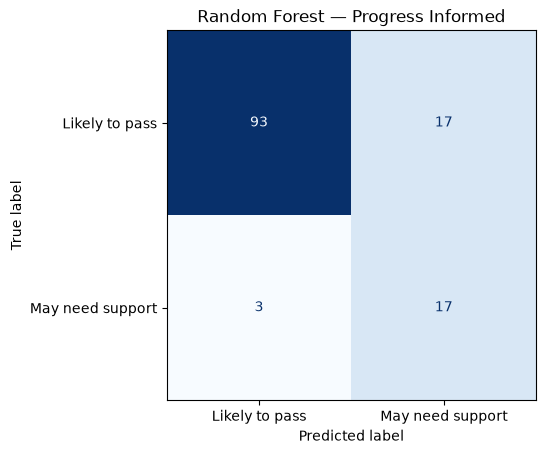

In [80]:
plot_confusion_matrix(
    result_forest_prog["confusion_matrix"],
    title="Random Forest — Progress Informed",
)

all_results.append(result_forest_prog)


## 7. Combine all four results

In [81]:
model_results_df = compare_model_results(all_results)
model_results_df


,experiment_name,model_name,training_accuracy,testing_accuracy,support_precision,support_recall,support_f1,roc_auc,cv_mean,cv_std,confusion_matrix
0,progress_informed,random_forest,0.901734,0.846154,0.500000,0.85,0.629630,0.945000,0.9625,0.050000,"[[93, 17], [3, 17]]"
1,early_warning,random_forest,0.786127,0.776923,0.384615,0.75,0.508475,0.816364,0.7500,0.079057,"[[86, 24], [5, 15]]"
2,progress_informed,decision_tree,0.949904,0.915385,0.736842,0.70,0.717949,0.933409,0.7125,0.183712,"[[105, 5], [6, 14]]"
3,early_warning,decision_tree,0.890173,0.815385,0.388889,0.35,0.368421,0.751818,0.3625,0.182859,"[[99, 11], [13, 7]]"


## 8. Fairness check (section 5.9)

In [ ]:
sex_results = evaluate_subgroups(
    forest_pipeline_prog,
    X_test_prog,
    y_test_prog,
    subgroup_column=df.loc[X_test_prog.index, "sex"],
    group_name="sex",
)

sex_results


,subgroup_variable,group,count,accuracy,support_precision,support_recall,support_f1,low_sample_warning
0,sex,F,80,0.8875,0.529412,0.9,0.666667,False
1,sex,M,50,0.7800,0.470588,0.8,0.592593,False


In [83]:
school_results = evaluate_subgroups(
    forest_pipeline_prog,
    X_test_prog,
    y_test_prog,
    subgroup_column=df.loc[X_test_prog.index, "school"],
    group_name="school",
)

school_results

,subgroup_variable,group,count,accuracy,support_precision,support_recall,support_f1,low_sample_warning
0,school,GP,84,0.916667,0.5,0.714286,0.588235,False
1,school,MS,46,0.717391,0.5,0.923077,0.648649,False


In [84]:
address_results = evaluate_subgroups(
    forest_pipeline_prog,
    X_test_prog,
    y_test_prog,
    subgroup_column=df.loc[X_test_prog.index, "address"],
    group_name="address",
)

address_results


,subgroup_variable,group,count,accuracy,support_precision,support_recall,support_f1,low_sample_warning
0,address,R,33,0.848485,0.642857,1.000000,0.782609,False
1,address,U,97,0.845361,0.400000,0.727273,0.516129,False


## SAVE THE RESULTS TO RESULTS

In [85]:
import json

results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

tree_forest_results = [
    result_tree_early,
    result_tree_prog,
    result_forest_early,
    result_forest_prog,
]

with open(results_dir / "tree_forest_results.json", "w") as f:
    json.dump(
        tree_forest_results,
        f,
        default=lambda x: x.tolist() if hasattr(x, "tolist") else float(x),
    )

print("Saved tree/forest results.")

Saved tree/forest results.
